# Visualizing the MT with Seaborn

In this notebook we analyze a dataset by making some basic calculations and visualizations. First of all we need to import the libraries pandas and seaborn. We use pandas for handling tabular data and seaborn for making visualizations.

In [27]:
import pandas as pd
import seaborn as sns

The dataset is based on a very simple query:

```
clause
  word lex* g_cons* sp* language*
```

I ran this query in the TF Browser app and exported the results. You can find the resulting file in this folder: the_whole_mt.tsv. 
We import the dataset in Python with pandas.

In [28]:
mt = pd.read_csv('the_whole_mt.tsv', encoding='utf16', sep='\t')

In [29]:
type(mt)

pandas.core.frame.DataFrame

The object "mt" is a so-called dataframe. A dataframe is a consists of rows and columns. Each row contains an observation, each column contains one variable, which can have its own datatype.

We will first inspect the dataset. How many rows and columns does the dataset have?

In [30]:
mt.shape

(426590, 14)

What are the column names?

In [31]:
mt.columns

Index(['R', 'S1', 'S2', 'S3', 'NODE1', 'TYPE1', 'TEXT1', 'NODE2', 'TYPE2',
       'TEXT2', 'g_cons2', 'language2', 'lex2', 'sp2'],
      dtype='object')

Inspect the first 5 rows.

In [32]:
mt.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,g_cons2,language2,lex2,sp2
0,1,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,1,word,בְּ,B,Hebrew,B,prep
1,2,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,2,word,רֵאשִׁ֖ית,R>CJT,Hebrew,R>CJT/,subs
2,3,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,3,word,בָּרָ֣א,BR>,Hebrew,BR>[,verb
3,4,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,4,word,אֱלֹהִ֑ים,>LHJM,Hebrew,>LHJM/,subs
4,5,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,5,word,אֵ֥ת,>T,Hebrew,>T,prep


If we summarize the data, pandas will put names in alphabetical order. However, we do not want that for the biblical books. They should stay in the canonical order of the MT. 

In [33]:
book_order = mt.S1.unique()
mt.S1 = pd.Categorical(mt.S1, categories=book_order, ordered=True)

## How many words are there in each book: barplot.

Each row contains information about one word in the MT. We use the function value_counts() to calculate how often each bookname occurs in the dataset.

In [34]:
word_counts = mt.S1.value_counts(sort=False)

In [35]:
word_counts

S1
Genesis          28764
Exodus           23748
Leviticus        17099
Numbers          23188
Deuteronomy      20128
Joshua           14526
Judges           14086
1_Samuel         18929
2_Samuel         15612
1_Kings          18685
2_Kings          17307
Isaiah           22931
Jeremiah         29736
Ezekiel          26182
Hosea             3146
Joel              1318
Amos              2780
Obadiah            392
Jonah              985
Micah             1895
Nahum              746
Habakkuk           897
Zephaniah         1037
Haggai             877
Zechariah         4471
Malachi           1187
Psalms           25372
Job              10912
Proverbs          8859
Ruth              1802
Song_of_songs     1682
Ecclesiastes      4233
Lamentations      1945
Esther            4621
Daniel            8072
Ezra              5268
Nehemiah          7842
1_Chronicles     15566
2_Chronicles     19764
Name: count, dtype: int64

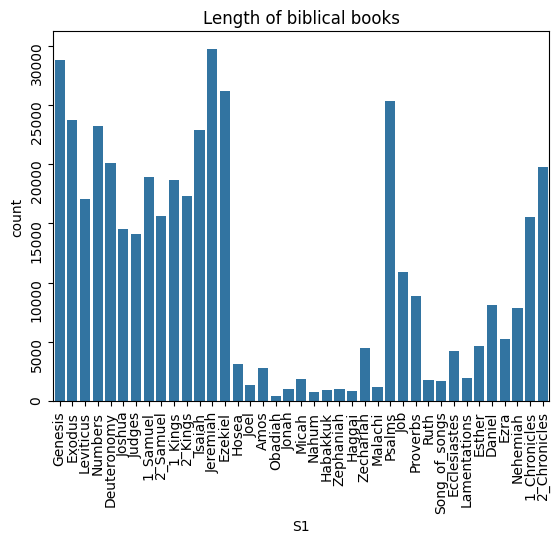

In [36]:
ax = sns.barplot(x=word_counts.index, 
                 y=word_counts, 
                 #hue=word_counts.index,
                 #palette='pastel',
                )

ax.set(title = 'Length of biblical books')
ax.tick_params(labelrotation=90)

## Which are the most frequently occurring lexemes in the MT: barplot.

We count how often each lexeme occurs in the MT using the function value_counts(). Pandas will organize the lexemes based on their frequencies. We plot the 100 most frequent lexemes. How are the lexemes distributed?

In [37]:
lex_counts = mt.lex2.value_counts()[:100]

In [38]:
lex_counts

lex2
W        51003
H        30392
L        20447
B        15768
>T       10987
         ...  
<BR[       548
GDWL/      526
<MD[       521
XMC/       506
TXT/       505
Name: count, Length: 100, dtype: int64

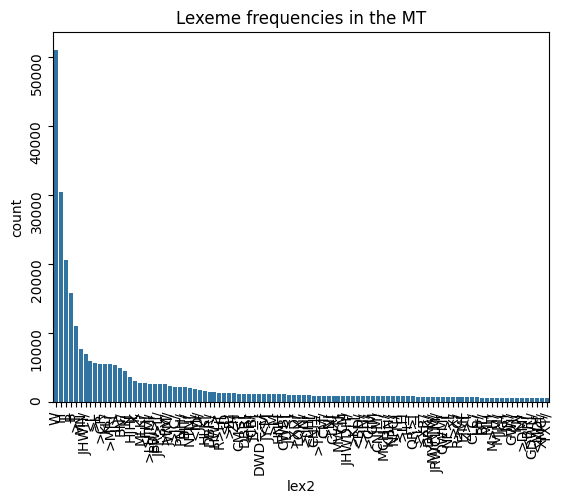

In [39]:
ax = sns.barplot(x=lex_counts.index, 
                 y=lex_counts, 
                 #hue=word_counts.index,
                 #palette='pastel',
                )

ax.set(title = 'Lexeme frequencies in the MT')
ax.tick_params(labelrotation=90)

## Distribution of אלהים and יהוה in Leviticus: stripchart.

How are אלהים and יהוה  distributed in the book of Leviticus? This is visualized in a stripchart.

In [40]:
god = mt[mt.lex2.isin(['>LHJM/', 'JHWH/'])]
god_in_lev = god[god.S1 == 'Leviticus']

In [41]:
god_in_lev.shape

(364, 14)

In [42]:
god_in_lev.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,g_cons2,language2,lex2,sp2
52518,52519,Leviticus,1,1,437873,clause,וַיְדַבֵּ֤ר יְהוָה֙ אֵלָ֔יו מֵאֹ֥הֶל מֹועֵ֖ד,52519,word,יְהוָה֙,JHWH,Hebrew,JHWH/,nmpr
52538,52539,Leviticus,1,2,437878,clause,כִּֽי־יַקְרִ֥יב מִכֶּ֛ם קָרְבָּ֖ן לַֽיהוָ֑ה,52539,word,יהוָ֑ה,JHWH,Hebrew,JHWH/,nmpr
52571,52572,Leviticus,1,3,437883,clause,אֶל־פֶּ֝תַח אֹ֤הֶל מֹועֵד֙ יַקְרִ֣יב אֹתֹ֔ו לִ...,52572,word,יְהוָֽה׃,JHWH,Hebrew,JHWH/,nmpr
52593,52594,Leviticus,1,5,437887,clause,וְשָׁחַ֛ט אֶת־בֶּ֥ן הַבָּקָ֖ר לִפְנֵ֣י יְהוָ֑ה,52594,word,יְהוָ֑ה,JHWH,Hebrew,JHWH/,nmpr
52691,52692,Leviticus,1,9,437901,clause,אִשֵּׁ֥ה רֵֽיחַ־נִיחֹ֖וחַ לַֽיהוָֽה׃ ס,52692,word,יהוָֽה׃ ס,JHWH,Hebrew,JHWH/,nmpr


How often does each value occur?

In [43]:
god_in_lev.lex2.value_counts()

lex2
JHWH/     311
>LHJM/     53
Name: count, dtype: int64

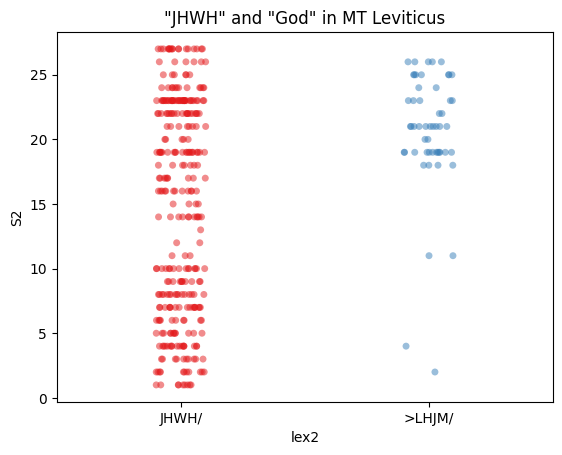

In [44]:
ax = sns.stripplot(y='S2',
                   x='lex2',
                   data=god_in_lev, 
                   hue='lex2',
                   palette='Set1',
                   alpha=.5,
                   size=5
                   ).set(title='"JHWH" and "God" in MT Leviticus')

## Which book has the longest average clause length?

In [45]:
mt.head()

,R,S1,S2,S3,NODE1,TYPE1,TEXT1,NODE2,TYPE2,TEXT2,g_cons2,language2,lex2,sp2
0,1,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,1,word,בְּ,B,Hebrew,B,prep
1,2,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,2,word,רֵאשִׁ֖ית,R>CJT,Hebrew,R>CJT/,subs
2,3,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,3,word,בָּרָ֣א,BR>,Hebrew,BR>[,verb
3,4,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,4,word,אֱלֹהִ֑ים,>LHJM,Hebrew,>LHJM/,subs
4,5,Genesis,1,1,427559,clause,בְּרֵאשִׁ֖ית בָּרָ֣א אֱלֹהִ֑ים אֵ֥ת הַשָּׁמַ֖י...,5,word,אֵ֥ת,>T,Hebrew,>T,prep


In [46]:
gen = mt[mt.S1 == 'Genesis']

In [47]:
gen.NODE1.value_counts().mean()

np.float64(4.8044095540337395)

In [48]:
mean_lengths = []

all_books = mt.S1.unique()

for book in all_books:
    book_df = mt[mt.S1 == book]
    mean_len = book_df.NODE1.value_counts().mean()
    mean_lengths.append(mean_len)

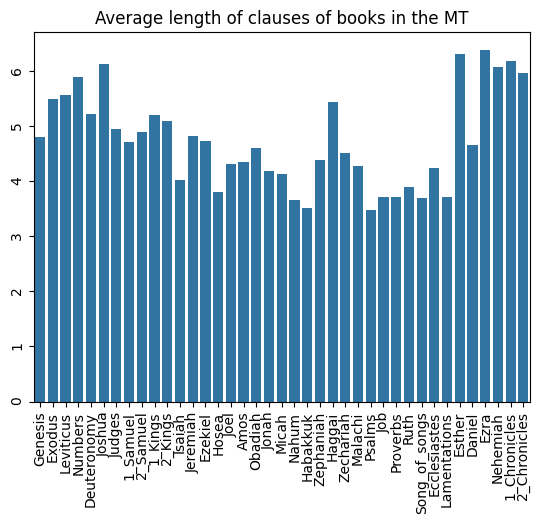

In [49]:
ax = sns.barplot(x=list(all_books), 
                 y=mean_lengths, 
                 #hue=word_counts.index,
                 #palette='pastel',
                )

ax.set(title = 'Average length of clauses of books in the MT')
ax.tick_params(labelrotation=90)

## Distribution of parts of speech in biblical books: Heatmap with cluster analysis.

I have read somehwere that the article ה occurs less often in the poetic books than in the prose books. Is that true? First, we make a crosstable using the pandas function crosstab().

Which books have similar distributions of the parts of speech? We will use cluster analysis to find this out.

In [50]:
mt_heb = mt[mt.language2 == 'Hebrew']

pos_df = pd.crosstab(mt_heb.S1, mt_heb.sp2)

Longer books tend to cluster together. Therefore, we normalize the data by dividing over the sums on every row. 

In [51]:
standardized_pos_df = pos_df.div(pos_df.sum(axis=1), axis=0)

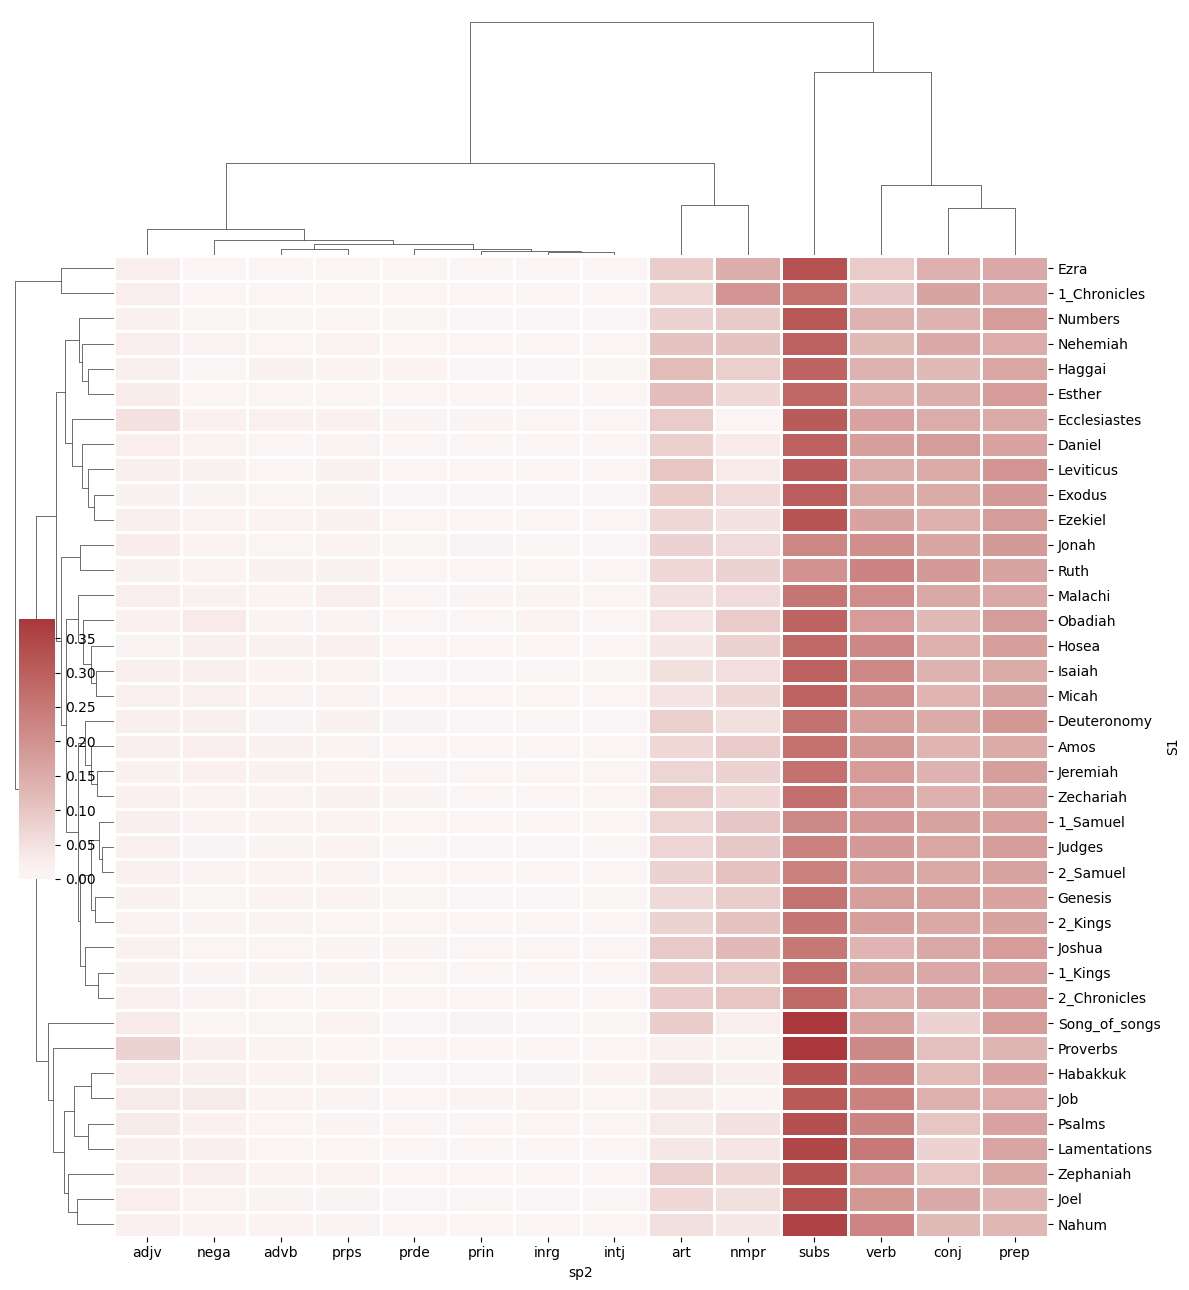

In [52]:
g = sns.clustermap(standardized_pos_df, 
                   center=0, 
                   cmap='vlag', # other color options: 'rocket', 'mako'
                   dendrogram_ratio=(.1, .2),
                   cbar_pos=(.02, .32, .03, .2),
                   linewidths=.75, figsize=(12, 13))